In [107]:
import copy
import os
import pickle
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm.auto import tqdm
from more_itertools import windowed

from emc.estimator.EMC import EMCLin
from emc.estimator.SLWE import SLWE
from emc.generator.markov import MarkovianSwitchingSystem
from emc.utils.paths import get_paths
from emc.utils.plot import get_mpl_conf_path, set_size
from emc.utils.sparse import sparse_to_dense

In [3]:
%load_ext autoreload
%autoreload 2

In [119]:
# synthetic data parameters
alphabet_cardinality = 4
mode_process_order = 1
subprocess_order = 1
number_of_subprocesses = 1
number_of_regimes = 1
regime_length_bounds = [500,1000]
rng = np.random.default_rng(42)

# generate data

mss_ins = MarkovianSwitchingSystem(
    alphabet_cardinality=alphabet_cardinality,
    mode_process_order=mode_process_order,
    subprocess_order=subprocess_order,
    number_of_subprocesses=number_of_subprocesses,
    rng_or_seed=42
)
mss_ins.generate_subprocess_sequence(
    number_of_regimes=number_of_regimes,
    avoid_loops=True
)
reg1 = mss_ins.generate_symbol_sequence(
    regime_length_bounds=regime_length_bounds
)

stats1 = Counter(reg1)

reg2 = rng.permutation(reg1.copy()).tolist()
stats2 = Counter(reg2)

print(f"Regime 1: len:{len(reg1)} {stats1}")
print(f"Regime 2: len:{len(reg2)} {stats2}")

seq = reg1 + reg2

true_mode_seq = np.concatenate((np.repeat(1, len(reg1)), np.repeat(2, len(reg2))))
change_points = [len(reg1)]

m1_tpm = mss_ins.subprocesses[0].transition_matrix
print(m1_tpm)

m2_freq = np.zeros((alphabet_cardinality, alphabet_cardinality))
for c in windowed(reg2, 2):
    m2_freq[c[0], c[1]] += 1
m2_tpm = m2_freq / m2_freq.sum(axis=1, keepdims=True)
print(m2_tpm)

Regime 1: len:943 Counter({0: 304, 1: 298, 2: 221, 3: 120})
Regime 2: len:943 Counter({0: 304, 1: 298, 2: 221, 3: 120})
[[0.45923057 0.46877836 0.05499985 0.01699121]
 [0.23946751 0.23242855 0.51503249 0.01307145]
 [0.26580348 0.01788928 0.2765881  0.43971914]
 [0.20758042 0.66078183 0.08250386 0.04913389]]
[[0.27960526 0.30263158 0.28289474 0.13486842]
 [0.36363636 0.29292929 0.22558923 0.11784512]
 [0.32579186 0.33484163 0.22171946 0.11764706]
 [0.325      0.36666667 0.15833333 0.15      ]]


In [ ]:
params = {"lambda_f": 0.92, "lambda_s": 0.95, "beta": 0.0, "delta_f": 0.45, "delta_s": 0.05, "eta_f": 0.4, "eta_s": 0.35, "tau": 25}
emc_ins = EMCLin(
    alpha=alphabet_cardinality,
    order=1,
    lambda_=[params["lambda_f"], params["lambda_s"]],
    beta=params["beta"],
    delta=[params["delta_f"], params["delta_s"]],
    eta=[params["eta_f"], params["eta_s"]],
    tau=params["tau"],
)

emc_p_hist = []
for o in seq:
    emc_ins.process_symbol(o)
    emc_p = copy.deepcopy(emc_ins.P)
    mat = sparse_to_dense(emc_p, k=emc_ins.order, alpha=alphabet_cardinality)
    emc_p_hist.append(mat)

emc_p_hist = np.array(emc_p_hist)

print(f"EMC estimates shape: {emc_p_hist.shape}")

EMC estimates shape: (1886, 4, 4)


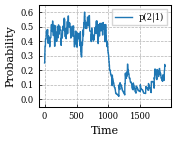

In [6]:
p_key = (2, 3)
p_key_str = f"p({p_key[1]}|{p_key[0]})".replace("2", "1").replace("3", "2")

plt.style.use("default")
plt.style.use(get_mpl_conf_path("pub"))
figsize = set_size(**{"width":"tpami_half", "aspect_ratio":1.25, "fraction":0.5})

fig, ax = plt.subplots(figsize=figsize)
sns.lineplot([p[p_key] for p in emc_p_hist], ax=ax, label=p_key_str)
ax.set_xlabel("Time")
ax.set_ylabel("Probability")
ax.set_ylim([-0.05, 0.65])
ax.set_yticks(np.arange(0, 0.7, 0.1))

fig_path = os.path.join("cond.pdf")
fig.savefig(fig_path, bbox_inches="tight")

plt.show()

In [7]:
slwe_ins = SLWE(alpha=alphabet_cardinality, lambda_=0.95)
slwe_ins.process_sequence(seq, progress=False)

estimates_all = np.array(slwe_ins.estimates).T
print(f"Estimates shape: {estimates_all.shape}")

Estimates shape: (4, 1887)


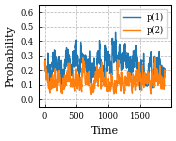

In [8]:
plt.style.use("default")
plt.style.use(get_mpl_conf_path("pub"))
figsize = set_size(**{"width":"tpami_half", "aspect_ratio":1.25, "fraction":0.5})

fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(data=estimates_all[2], label="p(1)", ax=ax)
sns.lineplot(data=estimates_all[3], label="p(2)", ax=ax)
ax.set_xlabel("Time")
ax.set_ylabel("Probability")
ax.set_ylim([-0.05, 0.65])
ax.set_yticks(np.arange(0, 0.7, 0.1))

fig_path = os.path.join("marg.pdf")
fig.savefig(fig_path, bbox_inches="tight")

plt.show()

In [36]:
print(len(slwe_ins.estimates))

1887


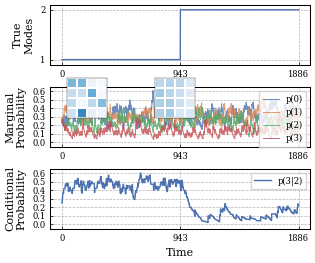

In [207]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use("default")
plt.style.use(get_mpl_conf_path("pub"))
# plt.rcParams["axes.labelsize"] = 6
figsize = set_size(**{"width":"tpami_half", "aspect_ratio":1.2, "fraction":0.9})

fig, axs = plt.subplots(nrows=3, figsize=figsize)

cmap = sns.color_palette("deep")

# true modes
sns.lineplot(data=true_mode_seq, color=cmap[0], ax=axs[0])
axs[0].set_ylabel("True\nModes")
axs[0].set_yticks([1, 2])

x0, y0 = 200, 1.275   # position in data coords
width_data, height_data = 0.4, 0.4 
ax_m1_hm = inset_axes(
    axs[0],
    width=width_data,
    height=height_data,
    bbox_to_anchor=(x0, y0, width_data, height_data),
    bbox_transform=ax.transData,
    loc='center',
    borderpad=0
)
m1_hm = sns.heatmap(m1_tpm, annot=False, fmt=".2f", annot_kws={"size": 2}, linewidth=0.25, cmap="Blues", vmin=0, vmax=1, square=True, cbar=False, ax=ax_m1_hm)
for spine in m1_hm.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.25)
    spine.set_visible(True)

x0, y0 = 900, 1.275   # position in data coords
width_data, height_data = 0.4, 0.4 
ax_m2_hm = inset_axes(
    axs[0],
    width=width_data,
    height=height_data,
    bbox_to_anchor=(x0, y0, width_data, height_data),
    bbox_transform=ax.transData,
    loc='center',
    borderpad=0
)
m2_hm = sns.heatmap(m2_tpm, annot=False, fmt=".2f", annot_kws={"size": 2}, linewidth=0.25, cmap="Blues", vmin=0, vmax=1, square=True, cbar=False, ax=ax_m2_hm)
for spine in m2_hm.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.25)
    spine.set_visible(True)

for ax in [ax_m1_hm, ax_m2_hm]:
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

# marginal
sns.lineplot(data=estimates_all[0], color=cmap[0], label="p(0)", linewidth=0.75, alpha=0.8, ax=axs[1])
sns.lineplot(data=estimates_all[1], color=cmap[1], label="p(1)", linewidth=0.75, alpha=0.8, ax=axs[1])
sns.lineplot(data=estimates_all[2], color=cmap[2], label="p(2)", linewidth=0.75, alpha=0.8, ax=axs[1])
sns.lineplot(data=estimates_all[3], color=cmap[3], label="p(3)", linewidth=0.75, alpha=0.8, ax=axs[1])
axs[1].set_ylabel("Marginal\nProbability")
axs[1].set_ylim([-0.05, 0.65])

# conditional
p_key = (2, 3)
p_key_str = f"p({p_key[1]}|{p_key[0]})"
sns.lineplot([p[p_key] for p in emc_p_hist], color=cmap[0], ax=axs[2], label=p_key_str)
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Conditional\nProbability")
axs[2].set_ylim([-0.05, 0.65])
axs[2].set_yticks(np.arange(0, 0.7, 0.1))

xticks = [0, *change_points, len(seq)]
for ax in axs:
    ax.set_xticks(xticks)
    ax.margins(x=0.05, y=0.1)

for ax in axs[1:]:
    ax.set_ylim([-0.05, 0.65])
    ax.set_yticks(np.arange(0, 0.7, 0.1))

fig_path = os.path.join("cond_need.pdf")
fig.savefig(fig_path, bbox_inches="tight")

# plt.show()